In [63]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

import pandas as pd

In [64]:
import tensorflow as tf

In [65]:
import torch 
import torchvision

In [66]:
data = pd.read_csv("../solutions/galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [67]:
cls = []
for c in data['class']:
    if c=='QSO': cls = np.append(cls, 1)
    elif c=='GALAXY': cls = np.append(cls, 0)

In [68]:
u_g = np.array(data['u']-data['g'])
g_r = np.array(data['g']-data['r'])
r_i = np.array(data['r']-data['i'])
i_z = np.array(data['i']-data['z'])
z = np.array(data['z1'])
zerr = np.array(data['zerr'])

In [69]:
X = np.array([u_g, g_r, r_i, i_z, z]).T
y = cls

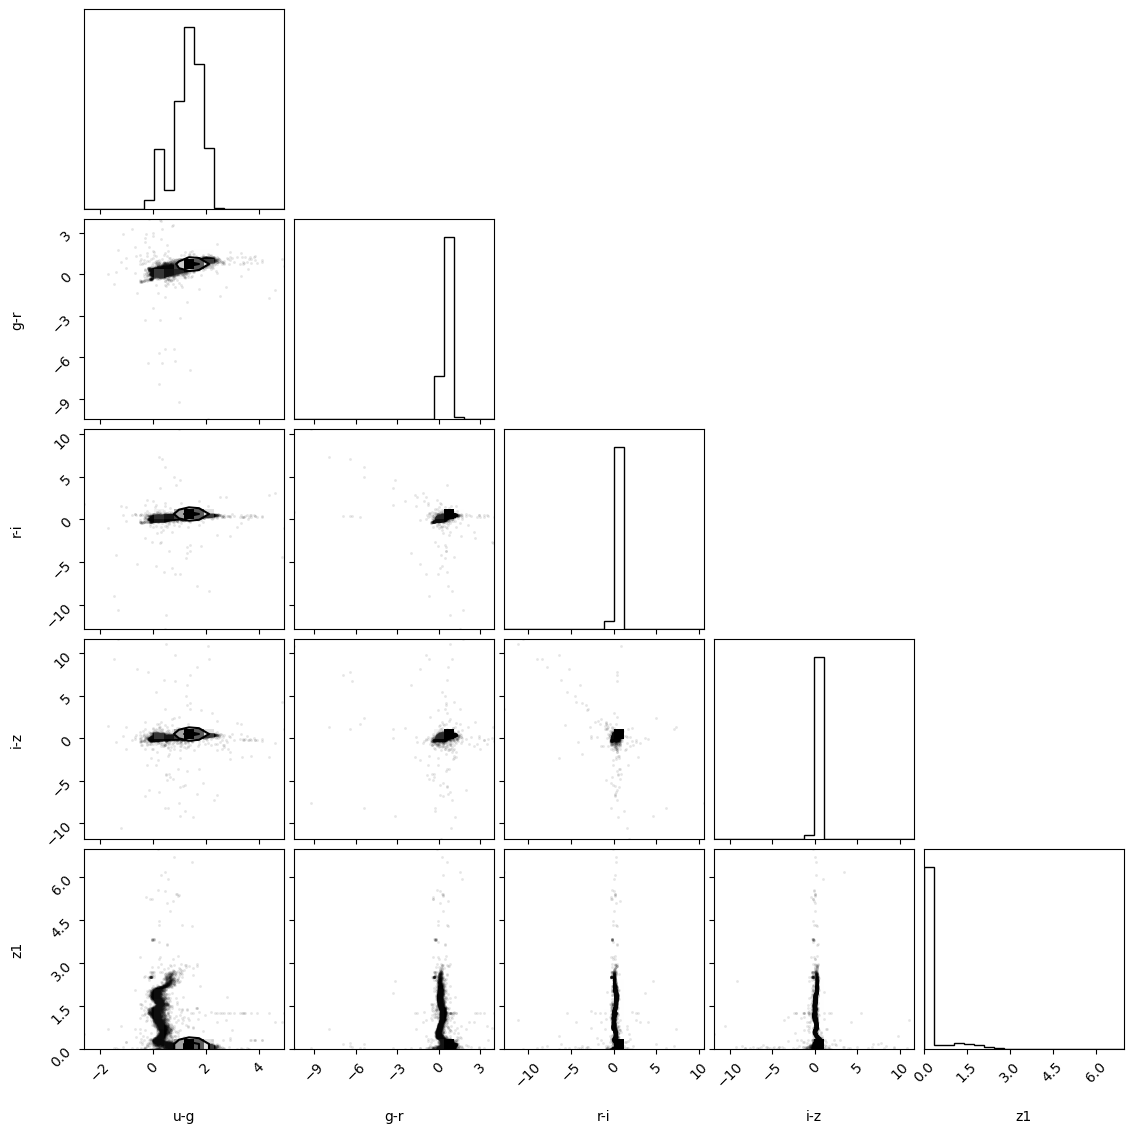

In [70]:
import corner
corner.corner(np.array([u_g,g_r,r_i,i_z,z]).T, labels=['u-g', 'g-r', 'r-i', 'i-z','z1']);

In [71]:
bins = np.linspace(-2,3,100)
bins2 = np.linspace(-4,4,100)

In [72]:
compl = []
cont = []
filt = []

# Without a Neural Network

In [75]:
(X_train_gmmb, X_test_gmmb), (y_train_gmmb, y_test_gmmb) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

In [77]:
from astroML.classification import GMMBayes

gmmb = GMMBayes(3) 
gmmb.fit(X_train_gmmb,y_train_gmmb)

y_pred_gmmb = gmmb.predict(X_test_gmmb)

In [82]:
completeness, contamination = completeness_contamination(y_pred_gmmb, y_test_gmmb)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.9642857142857143
contamination 0.055


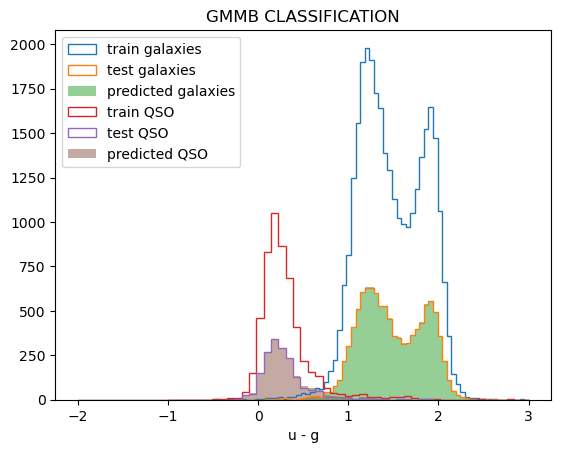

In [86]:
bins3 = np.linspace(-1,3,50)

plt.hist(X_train_gmmb[:,0][y_train_gmmb==0], bins, histtype='step', label='train galaxies')
plt.hist(X_test_gmmb[:,0][y_test_gmmb==0], bins, histtype='step', label='test galaxies')
plt.hist(X_test_gmmb[:,0][y_pred_gmmb==0], bins, label='predicted galaxies', alpha = 0.5)

plt.hist(X_train_gmmb[:,0][y_train_gmmb==1], bins3, histtype='step', label='train QSO')
plt.hist(X_test_gmmb[:,0][y_test_gmmb==1], bins3, histtype='step', label='test QSO')
plt.hist(X_test_gmmb[:,0][y_pred_gmmb==1], bins3, label='predicted QSO', alpha = 0.5)


plt.title('GMMB CLASSIFICATION')
plt.xlabel('u - g')
plt.legend();

In [ ]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='GMMB')

plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

plt.xlabel('false positive rate')
plt.ylabel('true positive rate');

# Simpler model

In [73]:
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xs = sc.fit_transform(X)

(X_train_full, X_test_full), (y_train_full, y_test_full) = split_samples(Xs, y, [0.75, 0.25],
                                                     random_state=0)

X_train_full.shape, y_train_full.shape

((37500, 5), (37500,))

In [13]:
from tensorflow import keras


keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)



X_valid, X_train = X_train_full[:12000], X_train_full[12000:]
y_valid, y_train = y_train_full[:12000], y_train_full[12000:]
X_test = X_test_full 
y_test = y_test_full

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)


(25500, 5) (25500,)
(12000, 5) (12000,)
(12500, 5) (12500,)


In [14]:
X_train = X_train[:,:,np.newaxis]
X_valid = X_valid[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(25500, 5, 1) (25500,)
(12000, 5, 1) (12000,)
(12500, 5, 1) (12500,)


In [15]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=(5,1)),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'), # Rectified Linear Unit
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=2, activation='softmax'),
])

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2026-06-27 12:01:35.565405: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 32)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578 (2.26 KB)

 Trainable params: 578 (2.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
# last_epoch = 30

# model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
# clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid))
last_epoch = 15 

early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=0.0001)


model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid), callbacks=[early_stopping_cb, reduce_lr_cb])

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7264 - loss: 0.5508 - val_accuracy: 0.9858 - val_loss: 0.2314 - learning_rate: 1.0000e-04
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9806 - loss: 0.1943 - val_accuracy: 0.9826 - val_loss: 0.1104 - learning_rate: 1.0000e-04
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9814 - loss: 0.1018 - val_accuracy: 0.9837 - val_loss: 0.0794 - learning_rate: 1.0000e-04
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9854 - loss: 0.0734 - val_accuracy: 0.9853 - val_loss: 0.0675 - learning_rate: 1.0000e-04
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9863 - loss: 0.0658 - val_accuracy: 0.9863 - val_loss: 0.0620 - learning_rate: 1.0000e-04
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9868 - loss: 0.0581 - val_accuracy: 0.9867 - val_loss: 0.0589 - learning_rate: 1.0000e-04
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 

In [18]:
X_new = X_test[:20]
y_proba = model.predict(X_new).round(4)
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


array([[9.977e-01, 2.300e-03],
       [9.991e-01, 9.000e-04],
       [9.992e-01, 8.000e-04],
       [9.983e-01, 1.700e-03],
       [2.800e-03, 9.972e-01],
       [9.973e-01, 2.700e-03],
       [9.968e-01, 3.200e-03],
       [9.989e-01, 1.100e-03],
       [9.990e-01, 1.000e-03],
       [9.772e-01, 2.280e-02],
       [9.876e-01, 1.240e-02],
       [9.991e-01, 9.000e-04],
       [9.994e-01, 6.000e-04],
       [9.991e-01, 9.000e-04],
       [9.985e-01, 1.500e-03],
       [9.991e-01, 9.000e-04],
       [9.956e-01, 4.400e-03],
       [9.776e-01, 2.240e-02],
       [9.910e-01, 9.000e-03],
       [1.000e-04, 9.999e-01]], dtype=float32)

In [19]:
y_pred = np.argmax(model.predict(X_test), axis=-1)

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [20]:
completeness, contamination = completeness_contamination(y_pred, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.937641723356009
contamination 0.011356843992827256


In [22]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape 

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(12500,)

In [23]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)

Text(0.5, 0, 'tpr')

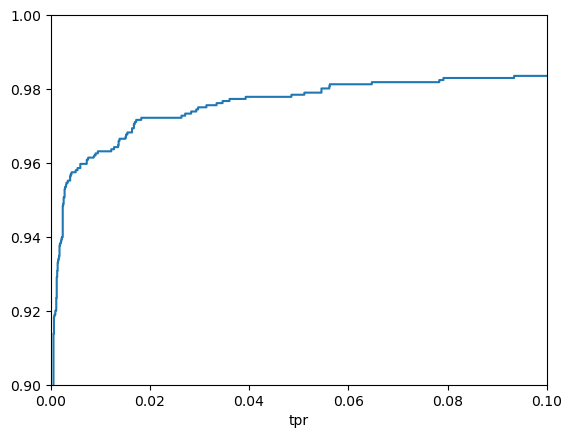

In [24]:
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC Curve');

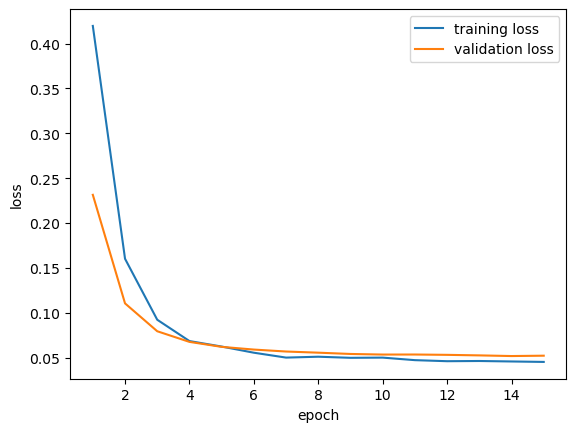

In [25]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.legend();

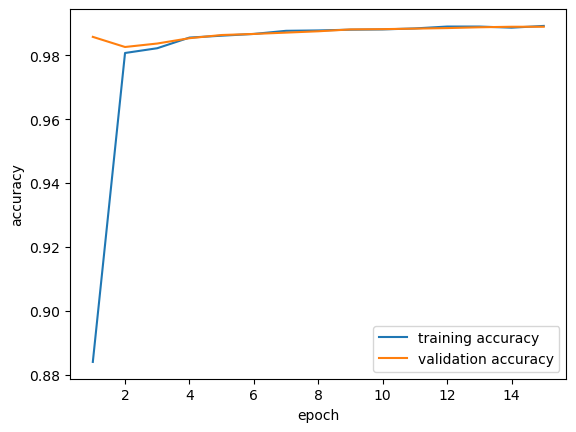

In [26]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.legend();

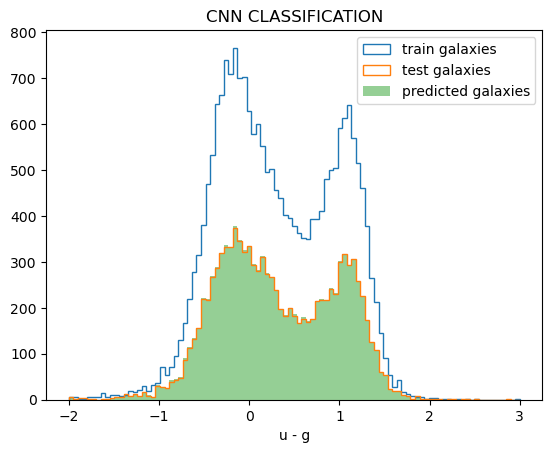

In [53]:
plt.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies')
plt.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies')
plt.hist(X_test[:,0][y_pred==0], bins, label='predicted galaxies', alpha = 0.5)

plt.hist(X_train[:,0][y_train==1], bins2, histtype='step', label='train QSO')
plt.hist(X_test[:,0][y_test==1], bins2, histtype='step', label='test QSO')
plt.hist(X_test[:,0][y_pred==1], bins2, label='predicted QSO', alpha = 0.5)

plt.title('CNN CLASSIFICATION')
plt.xlabel('u - g')
plt.legend();

# More complex model

In [29]:
from tensorflow import keras


keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)



X_valid, X_train = X_train_full[:12000], X_train_full[12000:]
y_valid, y_train = y_train_full[:12000], y_train_full[12000:]
X_test = X_test_full 
y_test = y_test_full

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)


(25500, 5) (25500,)
(12000, 5) (12000,)
(12500, 5) (12500,)


In [30]:
X_train = X_train[:,:,np.newaxis]
X_valid = X_valid[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(25500, 5, 1) (25500,)
(12000, 5, 1) (12000,)
(12500, 5, 1) (12500,)


In [31]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=(5,1)),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(32, 3, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5), 
    keras.layers.Dense(units=64, activation='relu'), 
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=2, activation='softmax'),
])

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [32]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 32)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,042 (66.57 KB)

 Trainable params: 17,042 (66.57 KB)

 Non-trainable params: 0 (0.00 B)

None


In [33]:
# last_epoch = 30

# model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
# clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid))
last_epoch = 15 # Increased epochs as training might take longer with callbacks and lower LR

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=0.00001)


model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid), callbacks=[early_stopping_cb, reduce_lr_cb])

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8571 - loss: 0.4812 - val_accuracy: 0.9858 - val_loss: 0.0795 - learning_rate: 1.0000e-04
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9821 - loss: 0.0966 - val_accuracy: 0.9883 - val_loss: 0.0666 - learning_rate: 1.0000e-04
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9850 - loss: 0.0769 - val_accuracy: 0.9886 - val_loss: 0.0625 - learning_rate: 1.0000e-04
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9861 - loss: 0.0711 - val_accuracy: 0.9888 - val_loss: 0.0589 - learning_rate: 1.0000e-04
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9849 - loss: 0.0709 - val_accuracy: 0.9888 - val_loss: 0.0544 - learning_rate: 1.0000e-04
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9859 - loss: 0.0633 - val_accuracy: 0.9891 - val_loss: 0.0537 - learning_rate: 1.0000e-04
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - a

In [34]:
X_new = X_test[:20]
y_proba = model.predict(X_new).round(4)
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


array([[9.966e-01, 3.400e-03],
       [9.992e-01, 8.000e-04],
       [9.991e-01, 9.000e-04],
       [9.989e-01, 1.100e-03],
       [1.350e-02, 9.865e-01],
       [9.982e-01, 1.800e-03],
       [9.991e-01, 9.000e-04],
       [9.991e-01, 9.000e-04],
       [9.992e-01, 8.000e-04],
       [9.991e-01, 9.000e-04],
       [9.982e-01, 1.800e-03],
       [9.992e-01, 8.000e-04],
       [9.993e-01, 7.000e-04],
       [9.992e-01, 8.000e-04],
       [9.989e-01, 1.100e-03],
       [9.991e-01, 9.000e-04],
       [9.992e-01, 8.000e-04],
       [9.978e-01, 2.200e-03],
       [9.994e-01, 6.000e-04],
       [5.100e-03, 9.949e-01]], dtype=float32)

In [35]:
y_pred = np.argmax(model.predict(X_test), axis=-1)

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [36]:
completeness, contamination = completeness_contamination(y_pred, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.953514739229025
contamination 0.023228803716608595


In [37]:
model

<Sequential name=sequential, built=True>

In [38]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape 

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


(12500,)

In [39]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)

(0.9, 1.0)

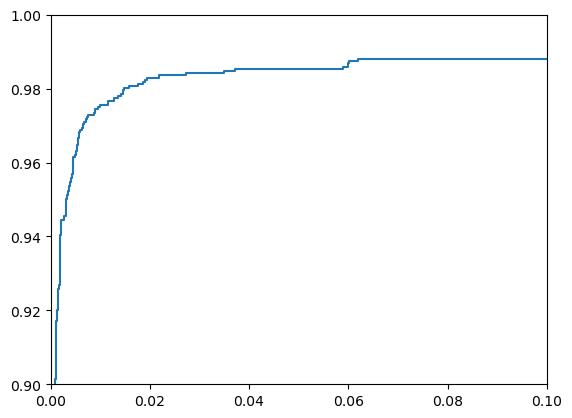

In [40]:
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title('ROC Curve');

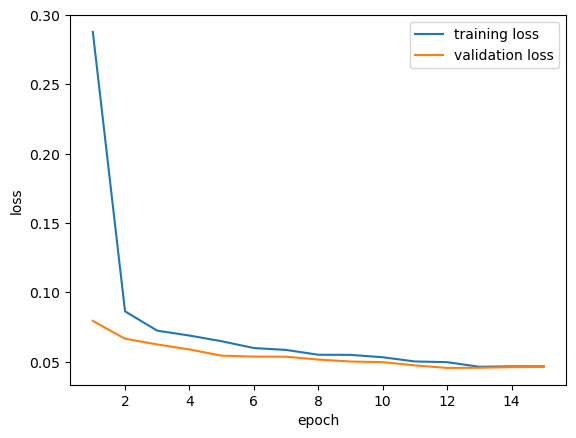

In [41]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.legend();

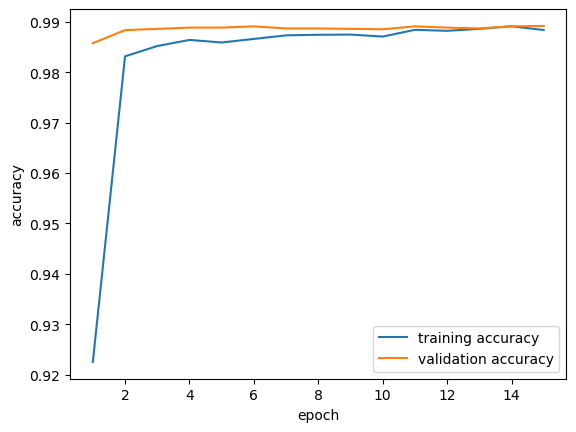

In [42]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.legend();

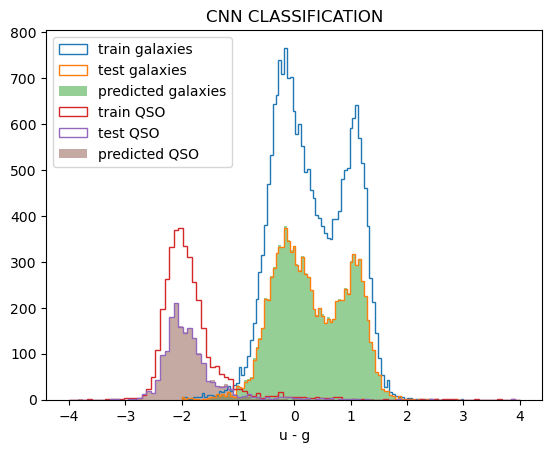

In [57]:
plt.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies')
plt.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies')
plt.hist(X_test[:,0][y_pred==0], bins, label='predicted galaxies', alpha = 0.5)

plt.hist(X_train[:,0][y_train==1], bins2, histtype='step', label='train QSO')
plt.hist(X_test[:,0][y_test==1], bins2, histtype='step', label='test QSO')
plt.hist(X_test[:,0][y_pred==1], bins2, label='predicted QSO', alpha = 0.5)


plt.title('CNN CLASSIFICATION')
plt.xlabel('u - g')
plt.legend();